# 🏆 Benchmarking: Comparativa de las 7 Estrategias de Agregación

**Federated Proactive Forest - Evaluación Comparativa Completa (NSL-KDD)**

Este notebook ejecuta secuencialmente las 7 estrategias de agregación (S1-S7) y compara sus rendimiento mediante métricas consolidadas.

## 📋 Contenido
1. Configuración inicial
2. Carga y preparación del dataset NSL-KDD
3. Funciones de evaluación consolidada
4. Ejecución secuencial de las 7 estrategias
5. Tabla comparativa final
6. Visualización de resultados

## 1️⃣ Configuración Inicial

Importamos las librerías necesarias y configuramos el entorno.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import time

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2️⃣ Carga y Preparación del Dataset

Cargamos el dataset `students_dropout.csv` y realizamos la preparación básica.

In [2]:
# Cargar dataset NSL-KDD (train y test separados)
train_df = pd.read_csv('../../../data/NSL-KDD_train.csv')
test_df = pd.read_csv('../../../data/NSL-KDD_test.csv')

print(f"📊 Dataset Train cargado: {train_df.shape[0]} muestras, {train_df.shape[1]} características")
print(f"📊 Dataset Test cargado: {test_df.shape[0]} muestras")
print(f"\nDistribución de la variable objetivo (Train):")
print(train_df['class'].value_counts())

📊 Dataset Train cargado: 151165 muestras, 42 características
📊 Dataset Test cargado: 34394 muestras

Distribución de la variable objetivo (Train):
class
normal     80792
anomaly    70373
Name: count, dtype: int64


In [3]:
# Preparar características y variable objetivo (NSL-KDD)
target_column = 'class'
feature_columns = [col for col in train_df.columns if col != target_column]

# Identificar columnas categóricas y numéricas
categorical_columns = train_df[feature_columns].select_dtypes(include=['object']).columns.tolist()
numerical_columns = train_df[feature_columns].select_dtypes(include=['number']).columns.tolist()

# Codificar variables categóricas
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    # Fit en train + test para cubrir todas las categorías
    all_values = pd.concat([train_df[col], test_df[col]]).astype(str)
    le.fit(all_values)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    label_encoders[col] = le

# Separar features y target (respeta train/test original)
X_train = train_df[feature_columns].values.astype(np.float64)
X_test = test_df[feature_columns].values.astype(np.float64)
y_train = train_df[target_column].values
y_test = test_df[target_column].values

# Codificar labels (fit en train + test para cubrir todas las clases)
le = LabelEncoder()
all_labels = np.concatenate([y_train, y_test])
le.fit(all_labels)
y_train_encoded = le.transform(y_train)
y_test_encoded = le.transform(y_test)
class_names = list(le.classes_)

# Escalar features (fit en train, transform en ambos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Train: {X_train_scaled.shape[0]} muestras")
print(f"✅ Test: {X_test_scaled.shape[0]} muestras")
print(f"✅ Clases: {class_names}")
print(f"✅ Columnas categóricas codificadas: {categorical_columns}")


✅ Train: 151165 muestras
✅ Test: 34394 muestras
✅ Clases: ['anomaly', 'normal']
✅ Columnas categóricas codificadas: ['protocol_type', 'service', 'flag']


## 3️⃣ Configuración del Benchmarking

Configuramos los parámetros del entrenamiento federado.

In [4]:
# Importar componentes del framework
import sys
sys.path.append('../../../')

from src.application.fl_orchestrator import FLEXOrchestrator, DatasetSplit
from src.domain.aggregation.aggregation_factory import AggregationFactory

print("✅ Componentes importados correctamente")

✅ Componentes importados correctamente


In [5]:
# ============================================
# ⚙️ CONFIGURACIÓN DEL BENCHMARKING
# ============================================

CONFIG = {
    'n_clients': 2,           # 📊 Número de clientes (modificar aquí)
    'distribution': 'iid',     # Distribución de datos
    'n_estimators': 100,      # Árboles por cliente
    'alpha_pf': 0.1,          # Parámetro Proactive Forest
    'verbose': False,
    'seed': 42,               # Seed para reproducibilidad
    'aggregation': {
        'f1_weight': 0.5,
        'pcd_weight': 0.5
    }
}

# Lista de estrategias a evaluar
STRATEGIES = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']

print("⚙️ Configuración del Benchmarking:")
print(f"   - Clientes: {CONFIG['n_clients']}")
print(f"   - Distribución: {CONFIG['distribution']}")
print(f"   - Árboles por cliente: {CONFIG['n_estimators']}")
print(f"   - Estrategias a evaluar: {STRATEGIES}")

⚙️ Configuración del Benchmarking:
   - Clientes: 2
   - Distribución: iid
   - Árboles por cliente: 100
   - Estrategias a evaluar: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']


## 4️⃣ Funciones de Evaluación Consolidada

Calculamos métricas consolidadas promediando clientes + global.

In [6]:
def calculate_consolidated_metrics(results, orchestrator, class_names):
    """
    Calcula métricas consolidadas promediando clientes + global.
    
    Para cada métrica (accuracy, F1, precisión, recall):
    - Calcula la métrica para cada cliente (usando predicción híbrida)
    - Calcula la métrica global
    - Promedia todas (n_clientes + 1 valores)
    
    Returns:
        dict: Métricas consolidadas
    """
    n_clients = len(results.client_ids)
    y_test = results.y_test
    
    # Calcular métricas por cliente (predicción híbrida)
    client_metrics = {
        'accuracy': [],
        'f1_score': [],
        'precision': [],
        'recall': []
    }
    
    for client_id in results.client_ids:
        hybrid_preds = results.client_hybrid_predictions[client_id]
        
        acc = accuracy_score(y_test, hybrid_preds)
        f1 = f1_score(y_test, hybrid_preds, average='macro', zero_division=0)
        prec = precision_score(y_test, hybrid_preds, average='macro', zero_division=0)
        rec = recall_score(y_test, hybrid_preds, average='macro', zero_division=0)
        
        client_metrics['accuracy'].append(acc)
        client_metrics['f1_score'].append(f1)
        client_metrics['precision'].append(prec)
        client_metrics['recall'].append(rec)
    
    # Métricas globales
    global_acc = results.global_accuracy
    global_f1 = results.global_macro_f1
    global_prec = results.global_report.macro_precision
    global_rec = results.global_report.macro_recall
    
    # Calcular promedios consolidados (cada entidad pesa igual: clientes + global)
    n_entities = n_clients + 1  # clientes + global
    consolidated = {
        'accuracy': (sum(client_metrics['accuracy']) + global_acc) / n_entities,
        'f1_score': (sum(client_metrics['f1_score']) + global_f1) / n_entities,
        'precision': (sum(client_metrics['precision']) + global_prec) / n_entities,
        'recall': (sum(client_metrics['recall']) + global_rec) / n_entities,
    }
    
    # Guardar también métricas individuales por cliente
    for i, client_id in enumerate(results.client_ids):
        consolidated[f'client_{client_id}_accuracy'] = client_metrics['accuracy'][i]
        consolidated[f'client_{client_id}_f1'] = client_metrics['f1_score'][i]
        consolidated[f'client_{client_id}_precision'] = client_metrics['precision'][i]
        consolidated[f'client_{client_id}_recall'] = client_metrics['recall'][i]
    
    # Guardar métricas globales
    consolidated['global_accuracy'] = global_acc
    consolidated['global_f1'] = global_f1
    consolidated['global_precision'] = global_prec
    consolidated['global_recall'] = global_rec
    
    # Información adicional
    consolidated['n_trees_global'] = results.n_trees_global
    consolidated['communication_cost'] = results.communication_cost
    
    return consolidated

In [7]:
def print_strategy_results(strategy_name, consolidated, client_metrics_details):
    """
    Muestra los resultados de una estrategia de forma detallada.
    """
    print("\n" + "=" * 80)
    print(f"📊 RESULTADOS - ESTRATEGIA {strategy_name}")
    print("=" * 80)
    
    # Métricas por cliente
    print("\n📈 MÉTRICAS POR CLIENTE (Predicción Híbrida):")
    print("-" * 80)
    print(f"{'Cliente':<12}{'Accuracy':<14}{'F1-Score':<14}{'Precisión':<14}{'Recall':<14}")
    print("-" * 80)
    
    # Extraer IDs únicos de clientes
    client_ids = set()
    for key in client_metrics_details.keys():
        if key.startswith('client_client_') and key.endswith('_accuracy'):
            # Extraer ID: 'client_client_0_accuracy' -> 'client_0'
            client_id = key.replace('client_', '', 1).replace('_accuracy', '')
            client_ids.add(client_id)
    
    for client_id in sorted(client_ids):
        acc = client_metrics_details.get(f'client_{client_id}_accuracy', 0.0)
        f1 = client_metrics_details.get(f'client_{client_id}_f1', 0.0)
        prec = client_metrics_details.get(f'client_{client_id}_precision', 0.0)
        rec = client_metrics_details.get(f'client_{client_id}_recall', 0.0)
        print(f"{client_id:<12}{acc:<14.4f}{f1:<14.4f}{prec:<14.4f}{rec:<14.4f}")
    
    # Métricas globales
    print("\n🌍 MÉTRICAS GLOBALES:")
    print("-" * 80)
    print(f"{'Accuracy':<14}{consolidated['global_accuracy']:.4f}")
    print(f"{'F1-Score':<14}{consolidated['global_f1']:.4f}")
    print(f"{'Precisión':<14}{consolidated['global_precision']:.4f}")
    print(f"{'Recall':<14}{consolidated['global_recall']:.4f}")
    
    # Métricas consolidadas (promedio)
    print("\n🎯 MÉTRICAS CONSOLIDADAS (Promedio Clientes + Global):")
    print("-" * 80)
    print(f"{'Accuracy':<14}{consolidated['accuracy']:.4f}")
    print(f"{'F1-Score':<14}{consolidated['f1_score']:.4f}")
    print(f"{'Precisión':<14}{consolidated['precision']:.4f}")
    print(f"{'Recall':<14}{consolidated['recall']:.4f}")
    
    # Información adicional
    print("\n📊 INFORMACIÓN ADICIONAL:")
    print(f"   - Árboles en bosque global: {consolidated['n_trees_global']}")
    print(f"   - Costo de comunicación (KB): {consolidated['communication_cost']:.2f}")

## 5️⃣ Ejecución Secuencial de las 7 Estrategias

Ejecutamos cada estrategia una tras otra y guardamos los resultados.

In [8]:
# Crear DatasetSplit (se reutiliza para todas las estrategias)
dataset_split = DatasetSplit(
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train_encoded,
    y_test=y_test_encoded,
    feature_names=feature_columns,
    class_names=class_names,
    dataset_name='NSL-KDD'
)

In [9]:
# Inicializar diccionario de resultados
all_results = {}

# Ejecutar cada estrategia
for strategy in STRATEGIES:
    print(f"\n\n{'='*80}")
    print(f"🔄 EJECUTANDO ESTRATEGIA {strategy}")
    print(f"{'='*80}")
    
    start_time = time.time()
    
    # Configurar entrenamiento
    config = CONFIG.copy()
    config['strategy'] = strategy
    
    # Crear orquestador
    orchestrator = FLEXOrchestrator.from_config(config)
    
    # Configurar federación
    orchestrator.setup_federation(dataset_split, seed=CONFIG['seed'])
    
    # Ejecutar ronda federada
    results = orchestrator.run_federated_round()
    
    # Calcular métricas consolidadas
    consolidated = calculate_consolidated_metrics(results, orchestrator, class_names)
    
    # Medir tiempo de ejecución
    elapsed_time = time.time() - start_time
    consolidated['execution_time'] = elapsed_time
    
    # Guardar resultados
    all_results[strategy] = {
        'consolidated': consolidated,
        'results': results,
        'orchestrator': orchestrator,
        'time': elapsed_time
    }
    
    # Mostrar resultados detallados
    print_strategy_results(strategy, consolidated, consolidated)
    
    print(f"\n⏱️ Tiempo de ejecución: {elapsed_time:.2f} segundos")
    print("=" * 80)



🔄 EJECUTANDO ESTRATEGIA S1

🌳 ÁRBOLES ENTRENADOS POR CLIENTE
  client_0: 9 árboles entrenados
  client_1: 9 árboles entrenados
  TOTAL: 18 árboles

📊 ÁRBOLES SELECCIONADOS (Estrategia: S1)
  client_0: 9/9 árboles seleccionados
  client_1: 9/9 árboles seleccionados

🌲 BOSQUE GLOBAL
  Tamaño final: 18 árboles

📈 TAMAÑO FINAL POR CLIENTE (sin duplicados)
  client_0: 9 locales + 9 globales externos (9 propios excluidos) = 18 árboles
  client_1: 9 locales + 9 globales externos (9 propios excluidos) = 18 árboles

[DEBUG] global_predictions type: <class 'numpy.str_'>, shape: (34394,)
[DEBUG] y_test type: <class 'numpy.int32'>, shape: (34394,)

📊 RESULTADOS - ESTRATEGIA S1

📈 MÉTRICAS POR CLIENTE (Predicción Híbrida):
--------------------------------------------------------------------------------
Cliente     Accuracy      F1-Score      Precisión     Recall        
--------------------------------------------------------------------------------
client_0    0.7312        0.7297        0.7631 

## 6️⃣ Tabla Comparativa Final

Mostramos una tabla comparativa con las métricas consolidadas de todas las estrategias.

In [10]:
# Crear DataFrame comparativo
comparative_data = []

for strategy in STRATEGIES:
    consolidated = all_results[strategy]['consolidated']
    
    row = {
        'Estrategia': strategy,
        'Accuracy (Consolidado)': consolidated['accuracy'],
        'F1-Score (Consolidado)': consolidated['f1_score'],
        'Precisión (Consolidado)': consolidated['precision'],
        'Recall (Consolidado)': consolidated['recall'],
        'Accuracy (Global)': consolidated['global_accuracy'],
        'F1-Score (Global)': consolidated['global_f1'],
        'Precisión (Global)': consolidated['global_precision'],
        'Recall (Global)': consolidated['global_recall'],
        'Árboles Globales': consolidated['n_trees_global'],
        'Tiempo (s)': all_results[strategy]['time'],
    }
    
    comparative_data.append(row)

comparative_df = pd.DataFrame(comparative_data)

# Mostrar tabla comparativa
print("\n" + "=" * 100)
print("📋 TABLA COMPARATIVA FINAL - LAS 7 ESTRATEGIAS")
print("=" * 100)
print(comparative_df.to_string(index=False, float_format="%.4f"))
print("=" * 100)


📋 TABLA COMPARATIVA FINAL - LAS 7 ESTRATEGIAS
Estrategia  Accuracy (Consolidado)  F1-Score (Consolidado)  Precisión (Consolidado)  Recall (Consolidado)  Accuracy (Global)  F1-Score (Global)  Precisión (Global)  Recall (Global)  Árboles Globales  Tiempo (s)
        S1                  0.7428                  0.7409                   0.7695                0.7924             0.7499             0.7477              0.7733           0.7978                18   2288.0551
        S2                  0.7131                  0.7122                   0.7537                0.7697             0.7163             0.7153              0.7552           0.7721                18   3719.7909
        S3                  0.7320                  0.7305                   0.7640                0.7844             0.7374             0.7357              0.7667           0.7885                18   2636.0959
        S4                  0.7425                  0.7406                   0.7693                0.7922    

In [11]:
# Guardar resultados en CSV
comparative_df.to_csv('../../../data/benchmarking_results_nsl.csv', index=False)
print(f"\n✅ Resultados guardados en: ../../../data/benchmarking_results_nsl.csv")


✅ Resultados guardados en: ../../../data/benchmarking_results_nsl.csv


## 7️⃣ Visualización de Resultados

Gráficos comparativos de las métricas consolidadas.

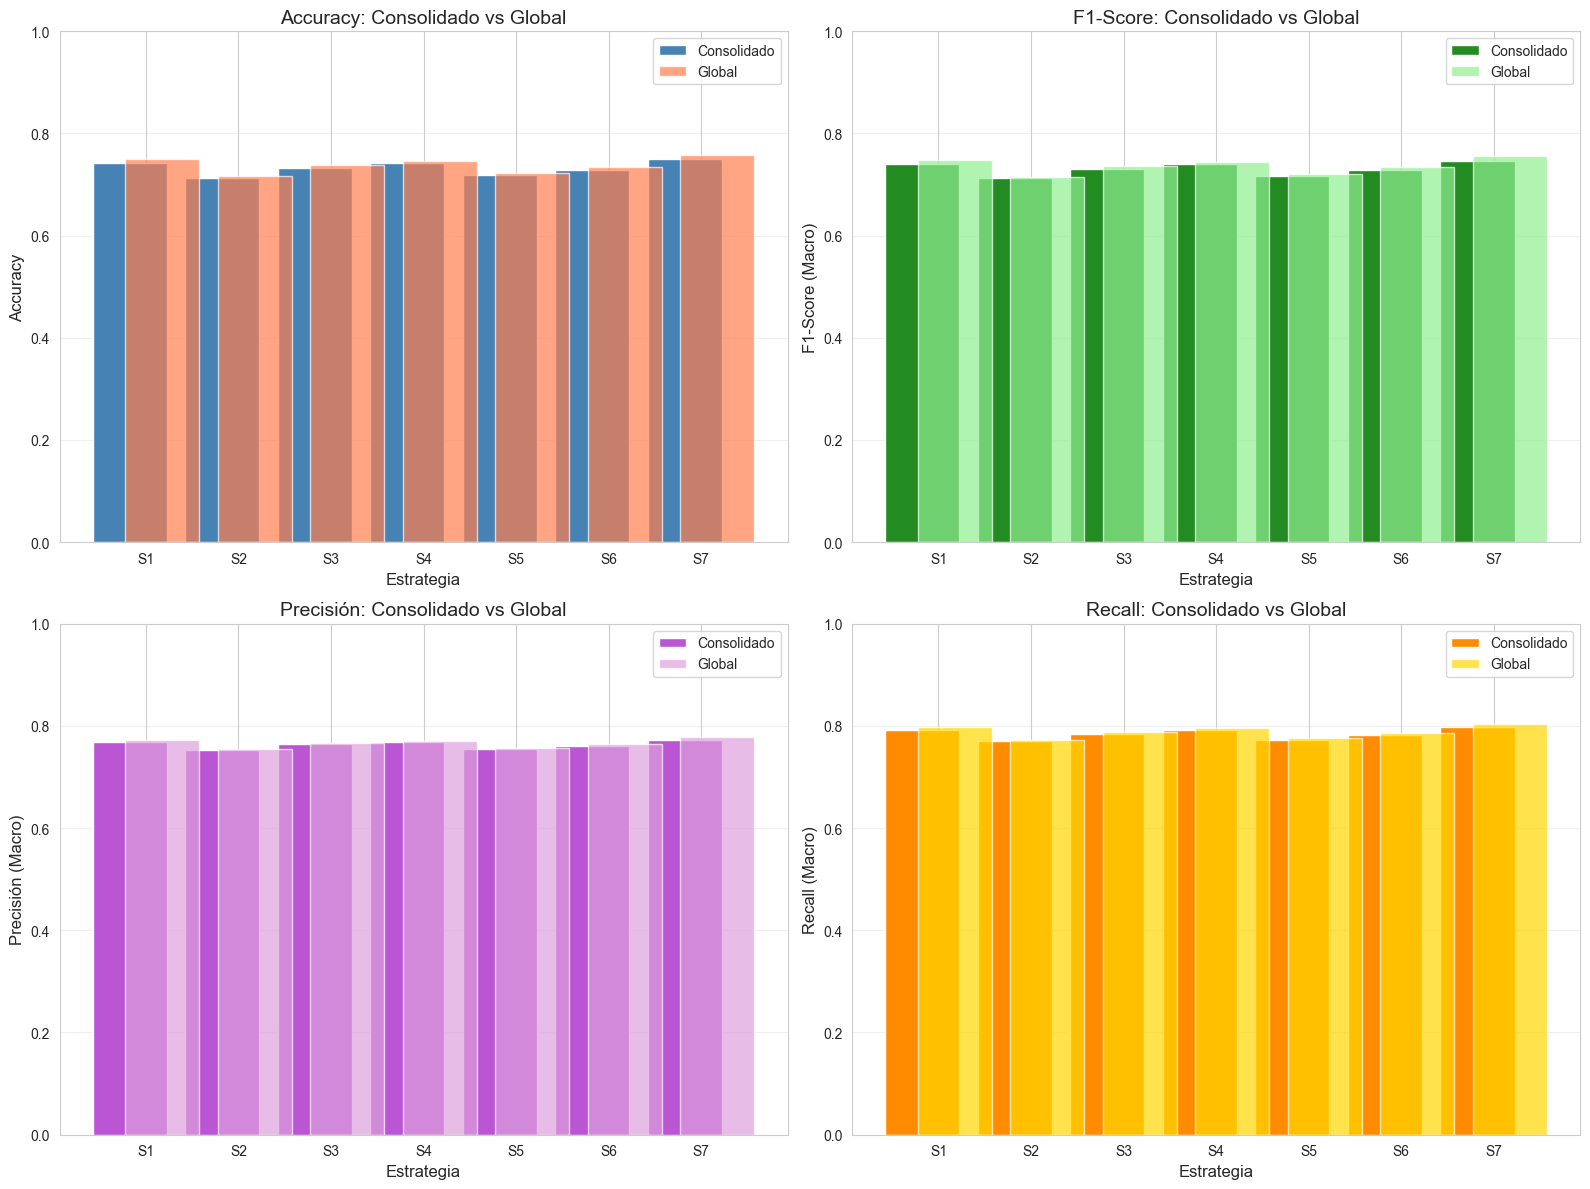

In [12]:
# Gráfico de barras comparativo - Métricas Consolidadas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

strategies = comparative_df['Estrategia'].values
x = np.arange(len(strategies))
width = 0.35

# 1. Accuracy
ax1 = axes[0, 0]
ax1.bar(x, comparative_df['Accuracy (Consolidado)'].values, color='steelblue', label='Consolidado')
ax1.bar(x + width, comparative_df['Accuracy (Global)'].values, color='coral', label='Global', alpha=0.7)
ax1.set_xlabel('Estrategia', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy: Consolidado vs Global', fontsize=14)
ax1.set_xticks(x + width/2)
ax1.set_xticklabels(strategies)
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# 2. F1-Score
ax2 = axes[0, 1]
ax2.bar(x, comparative_df['F1-Score (Consolidado)'].values, color='forestgreen', label='Consolidado')
ax2.bar(x + width, comparative_df['F1-Score (Global)'].values, color='lightgreen', label='Global', alpha=0.7)
ax2.set_xlabel('Estrategia', fontsize=12)
ax2.set_ylabel('F1-Score (Macro)', fontsize=12)
ax2.set_title('F1-Score: Consolidado vs Global', fontsize=14)
ax2.set_xticks(x + width/2)
ax2.set_xticklabels(strategies)
ax2.legend()
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

# 3. Precisión
ax3 = axes[1, 0]
ax3.bar(x, comparative_df['Precisión (Consolidado)'].values, color='mediumorchid', label='Consolidado')
ax3.bar(x + width, comparative_df['Precisión (Global)'].values, color='plum', label='Global', alpha=0.7)
ax3.set_xlabel('Estrategia', fontsize=12)
ax3.set_ylabel('Precisión (Macro)', fontsize=12)
ax3.set_title('Precisión: Consolidado vs Global', fontsize=14)
ax3.set_xticks(x + width/2)
ax3.set_xticklabels(strategies)
ax3.legend()
ax3.set_ylim(0, 1)
ax3.grid(axis='y', alpha=0.3)

# 4. Recall
ax4 = axes[1, 1]
ax4.bar(x, comparative_df['Recall (Consolidado)'].values, color='darkorange', label='Consolidado')
ax4.bar(x + width, comparative_df['Recall (Global)'].values, color='gold', label='Global', alpha=0.7)
ax4.set_xlabel('Estrategia', fontsize=12)
ax4.set_ylabel('Recall (Macro)', fontsize=12)
ax4.set_title('Recall: Consolidado vs Global', fontsize=14)
ax4.set_xticks(x + width/2)
ax4.set_xticklabels(strategies)
ax4.legend()
ax4.set_ylim(0, 1)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Adrián Rodríguez\AppData\Local\Temp\ipykernel_8040\752285305.py:36: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
C:\Users\Adrián Rodríguez\AppData\Roaming\Python\Python38\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


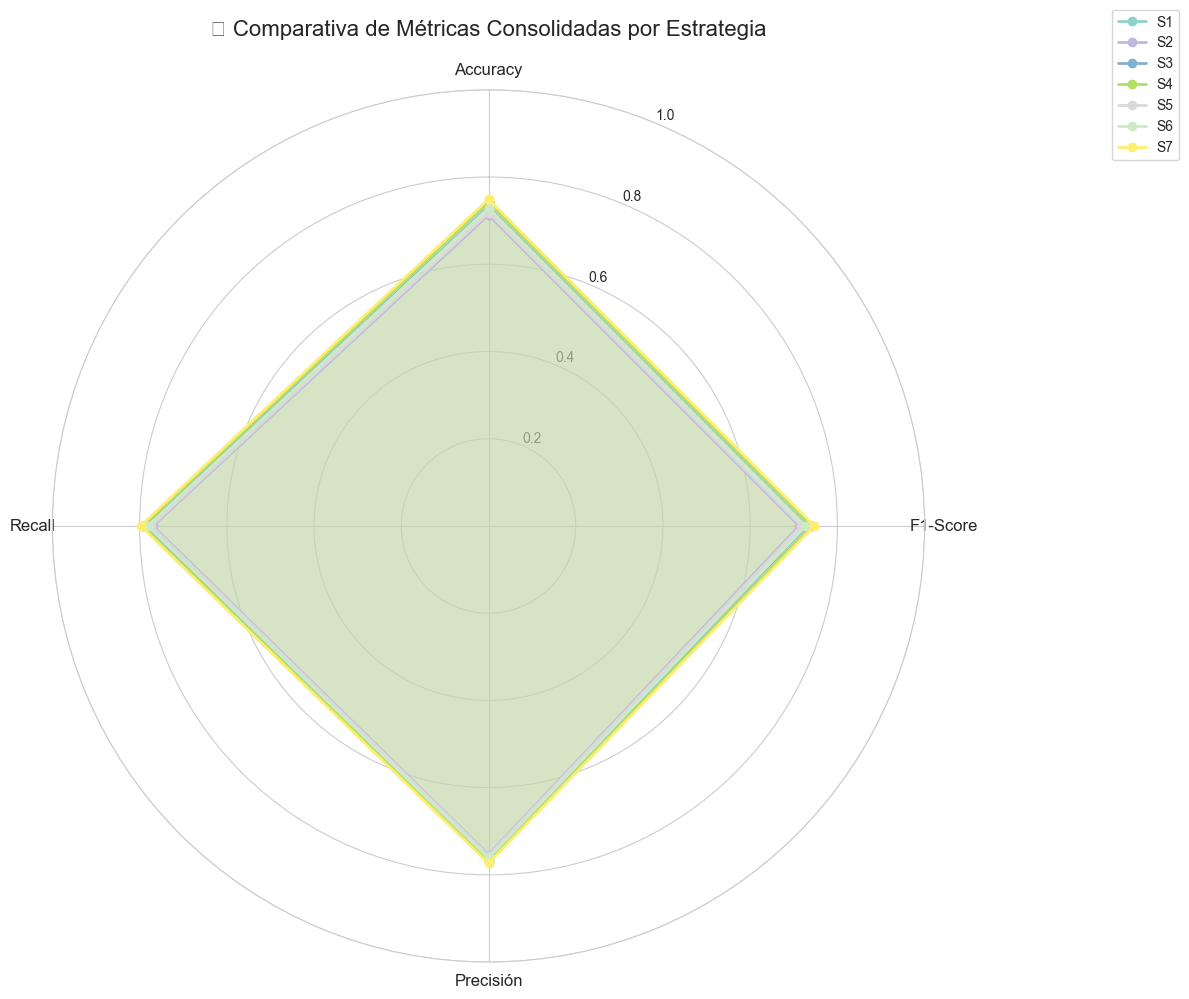

In [13]:
# Gráfico de radar comparativo - Todas las métricas consolidadas
from math import pi

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, polar=True)

categories = ['Accuracy', 'F1-Score', 'Precisión', 'Recall']
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

colors = plt.cm.Set3(np.linspace(0, 1, len(STRATEGIES)))

for i, strategy in enumerate(STRATEGIES):
    consolidated = all_results[strategy]['consolidated']
    values = [
        consolidated['accuracy'],
        consolidated['f1_score'],
        consolidated['precision'],
        consolidated['recall']
    ]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=strategy, color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=12)
ax.set_rgrids([0.2, 0.4, 0.6, 0.8, 1.0], fontsize=10)
ax.set_ylim(0, 1)

plt.title('🎯 Comparativa de Métricas Consolidadas por Estrategia', fontsize=16, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 8️⃣ Métricas por Cliente

Gráfico de barras mostrando las métricas individuales de cada cliente.

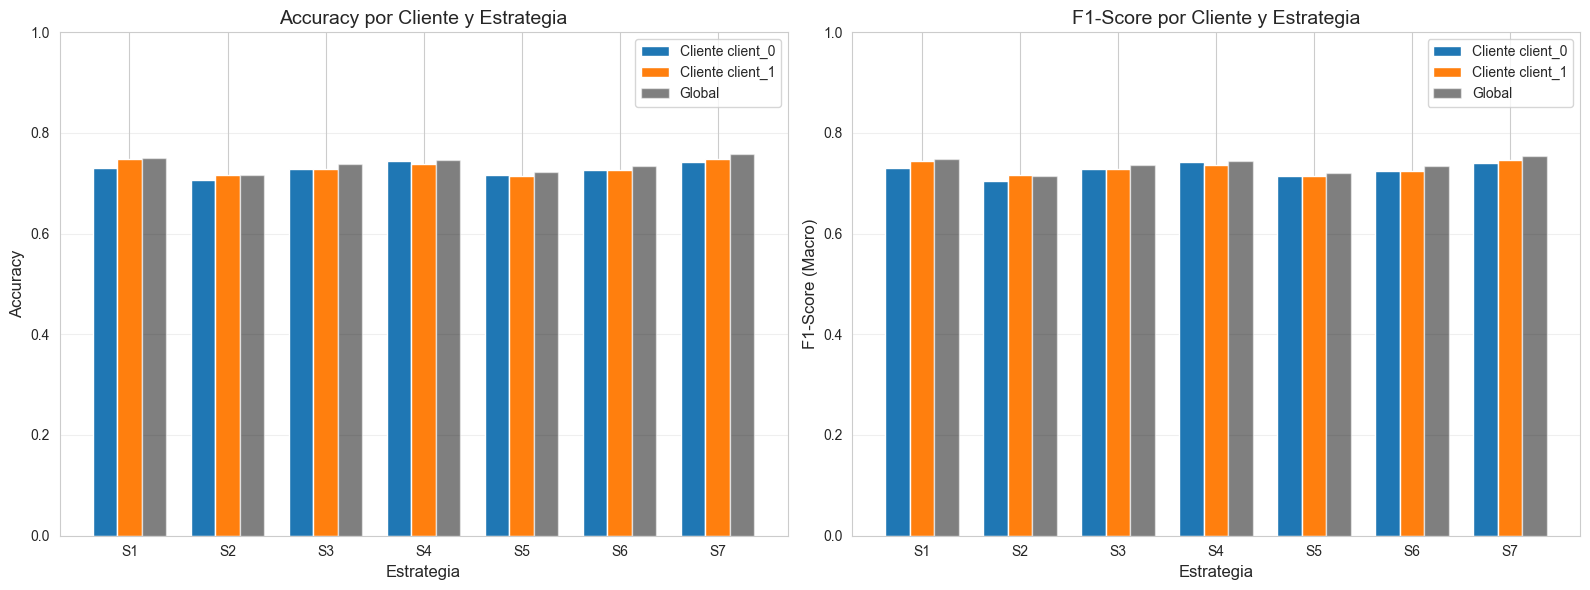

In [14]:
# Gráfico de barras - Accuracy por cliente para cada estrategia
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Extraer IDs de clientes
client_ids = []
for key in all_results['S1']['consolidated'].keys():
    if key.startswith('client_client_') and key.endswith('_accuracy'):
        # Extraer ID: 'client_client_0_accuracy' -> 'client_0'
        client_num = key.replace('client_', '', 1).replace('_accuracy', '')
        if client_num not in client_ids:
            client_ids.append(client_num)

# 1. Accuracy por cliente
ax1 = axes[0]
x = np.arange(len(STRATEGIES))
width = 0.25

for i, client_num in enumerate(client_ids):
    values = []
    for strategy in STRATEGIES:
        consolidated = all_results[strategy]['consolidated']
        values.append(consolidated.get(f'client_{client_num}_accuracy', 0.0))
    ax1.bar(x + i*width, values, width, label=f'Cliente {client_num}')

# Añadir global
global_values = [all_results[s]['consolidated']['global_accuracy'] for s in STRATEGIES]
ax1.bar(x + len(client_ids)*width, global_values, width, label='Global', color='black', alpha=0.5)

ax1.set_xlabel('Estrategia', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy por Cliente y Estrategia', fontsize=14)
ax1.set_xticks(x + width * (len(client_ids) / 2))
ax1.set_xticklabels(STRATEGIES)
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# 2. F1-Score por cliente
ax2 = axes[1]

for i, client_num in enumerate(client_ids):
    values = []
    for strategy in STRATEGIES:
        consolidated = all_results[strategy]['consolidated']
        values.append(consolidated.get(f'client_{client_num}_f1', 0.0))
    ax2.bar(x + i*width, values, width, label=f'Cliente {client_num}')

# Añadir global
global_f1_values = [all_results[s]['consolidated']['global_f1'] for s in STRATEGIES]
ax2.bar(x + len(client_ids)*width, global_f1_values, width, label='Global', color='black', alpha=0.5)

ax2.set_xlabel('Estrategia', fontsize=12)
ax2.set_ylabel('F1-Score (Macro)', fontsize=12)
ax2.set_title('F1-Score por Cliente y Estrategia', fontsize=14)
ax2.set_xticks(x + width * (len(client_ids) / 2))
ax2.set_xticklabels(STRATEGIES)
ax2.legend()
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9️⃣ Resumen Ejecutivo

Identificamos las mejores estrategias por cada métrica.

In [15]:
# Encontrar la mejor estrategia por cada métrica
print("\n" + "=" * 80)
print("🏆 MEJORES ESTRATEGIAS POR MÉTRICA")
print("=" * 80)

metrics = ['accuracy', 'f1_score', 'precision', 'recall']
metric_names = ['Accuracy', 'F1-Score', 'Precisión', 'Recall']

for metric, name in zip(metrics, metric_names):
    best_strategy = max(STRATEGIES, key=lambda s: all_results[s]['consolidated'][metric])
    best_value = all_results[best_strategy]['consolidated'][metric]
    print(f"\n🥇 {name}: {best_strategy} ({best_value:.4f})")
    
    # Top 3
    sorted_strategies = sorted(STRATEGIES, key=lambda s: all_results[s]['consolidated'][metric], reverse=True)
    print("   Top 3:")
    for i, s in enumerate(sorted_strategies[:3], 1):
        value = all_results[s]['consolidated'][metric]
        print(f"      {i}. {s}: {value:.4f}")

# Estrategia más rápida
fastest_strategy = min(STRATEGIES, key=lambda s: all_results[s]['time'])
fastest_time = all_results[fastest_strategy]['time']
print(f"\n⚡ Más Rápida: {fastest_strategy} ({fastest_time:.2f} segundos)")

# Estrategia con menos árboles
min_trees_strategy = min(STRATEGIES, key=lambda s: all_results[s]['consolidated']['n_trees_global'])
min_trees = all_results[min_trees_strategy]['consolidated']['n_trees_global']
print(f"\n🌳 Menos Árboles: {min_trees_strategy} ({min_trees} árboles)")

print("\n" + "=" * 80)


🏆 MEJORES ESTRATEGIAS POR MÉTRICA

🥇 Accuracy: S7 (0.7491)
   Top 3:
      1. S7: 0.7491
      2. S1: 0.7428
      3. S4: 0.7425

🥇 F1-Score: S7 (0.7470)
   Top 3:
      1. S7: 0.7470
      2. S1: 0.7409
      3. S4: 0.7406

🥇 Precisión: S7 (0.7735)
   Top 3:
      1. S7: 0.7735
      2. S1: 0.7695
      3. S4: 0.7693

🥇 Recall: S7 (0.7976)
   Top 3:
      1. S7: 0.7976
      2. S1: 0.7924
      3. S4: 0.7922

⚡ Más Rápida: S1 (2288.06 segundos)

🌳 Menos Árboles: S1 (18 árboles)



## ✅ Conclusiones

Este notebook ha ejecutado las 7 estrategias de agregación y ha calculado:

1. **Métricas por cliente**: Accuracy, F1-Score, Precisión y Recall para cada cliente usando predicción híbrida
2. **Métricas globales**: Rendimiento del bosque global agregado
3. **Métricas consolidadas**: Promedio de (clientes + global) para una referencia única
4. **Tabla comparativa**: Comparativa directa de todas las estrategias
5. **Visualizaciones**: Gráficos de barras y radar para análisis visual

**Métricas Consolidadas:**
- Se calcula promediando: `(sum(clientes) + global) / (n_clients + 1)`
- Esto da igual importancia al rendimiento local y global
- Proporciona una visión holística del sistema federado

**Para modificar el número de clientes:**
- Cambiar `CONFIG['n_clients']` en la celda de configuración
- Ejecutar el notebook desde el inicio